<a href="https://colab.research.google.com/github/Josev21/TPI-Data-Analytics/blob/main/data_analytcs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import io
from google.colab import files

# Llama a la ventana de diálogo para seleccionar el archivo.
# Cuando ejecutes esta celda, aparecerá un botón 'Elegir Archivos'.
uploaded = files.upload()

# Obtener el nombre del archivo cargado (solo funciona si es un único archivo)
file_name = next(iter(uploaded))
print(f"Nombre del archivo subido: {file_name}")

# Leer el archivo CSV/Excel en un DataFrame de Pandas
try:
    # Intenta leer como CSV
    df_ventas = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))
    print("\n✅ Archivo cargado como CSV exitosamente.")
except Exception:
    try:
        # Si no es CSV, intenta leerlo como Excel (si aplica a tu archivo)
        df_ventas = pd.read_excel(io.BytesIO(uploaded[file_name]))
        print("\n✅ Archivo cargado como Excel exitosamente.")
    except Exception as e:
        print(f"\n❌ Error al leer el archivo. Asegúrate de que sea CSV o Excel. Error: {e}")

# Muestra el resultado para confirmar el éxito de la carga
print("\nPrimeras 5 filas del DataFrame:")
print(df_ventas.head())
print("\nInformación de las columnas (Tipos de datos):")
df_ventas.info()


Saving clientes.csv to clientes.csv
Saving marketing.csv to marketing.csv
Saving ventas.csv to ventas.csv
Nombre del archivo subido: clientes.csv

✅ Archivo cargado como CSV exitosamente.

Primeras 5 filas del DataFrame:
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25        Posadas  24735.04
2           3       Filip Castagne    50    Resistencia  35744.85
3           4          Liuka Luard    39   Bahía Blanca  27647.96
4           5        Dore Cockshtt    28        Rosario  28245.65

Información de las columnas (Tipos de datos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-nu

In [30]:
import pandas as pd
import io
# No necesitas llamar a files.upload() de nuevo, ¡los archivos ya están en 'uploaded'!

print("Cargando DataFrames...")

# 1. Leer clientes.csv
if 'clientes.csv' in uploaded:
    df_clientes = pd.read_csv(io.StringIO(uploaded['clientes.csv'].decode('utf-8')))
    print(f"✅ df_clientes cargado. Filas: {df_clientes.shape[0]}")

# 2. Leer marketing.csv
if 'marketing.csv' in uploaded:
    df_marketing = pd.read_csv(io.StringIO(uploaded['marketing.csv'].decode('utf-8')))
    print(f"✅ df_marketing cargado. Filas: {df_marketing.shape[0]}")

# 3. Leer ventas.csv
if 'ventas.csv' in uploaded:
    df_ventas = pd.read_csv(io.StringIO(uploaded['ventas.csv'].decode('utf-8')))
    print(f"✅ df_ventas cargado. Filas: {df_ventas.shape[0]}")

print("\n¡Listos para trabajar!")

Cargando DataFrames...
✅ df_clientes cargado. Filas: 567
✅ df_marketing cargado. Filas: 90
✅ df_ventas cargado. Filas: 3035

¡Listos para trabajar!


In [31]:
print("--- Vista Previa de los 3 DataFrames (Primeras 5 Filas) ---")

# 1. DataFrame de Clientes
print("\n===== df_clientes.head() =====")
print(df_clientes.head())

# 2. DataFrame de Marketing
print("\n===== df_marketing.head() =====")
print(df_marketing.head())

# 3. DataFrame de Ventas
print("\n===== df_ventas.head() =====")
print(df_ventas.head())


--- Vista Previa de los 3 DataFrames (Primeras 5 Filas) ---

===== df_clientes.head() =====
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25        Posadas  24735.04
2           3       Filip Castagne    50    Resistencia  35744.85
3           4          Liuka Luard    39   Bahía Blanca  27647.96
4           5        Dore Cockshtt    28        Rosario  28245.65

===== df_marketing.head() =====
   id_campanha         producto  canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared     TV   4.81   20/03/2024  03/05/2024
1           12           Tablet   RRSS   3.40   26/03/2024  13/05/2024
2           32  Lámpara de mesa  Email   5.54   28/03/2024  20/04/2024
3           21       Smartphone   RRSS   6.37   29/03/2024  16/05/2024
4           58         Alfombra  Email   4.25   31/03/2024  05/05/2024

===== df_ventas.head() =====
   id_venta           p

In [67]:
# ASUMIMOS que el PASO 1 (limpieza de precio y cantidad, y manejo de nulos) ya se ejecutó

# 1. Creación de la columna 'ventas_brutas' (Operador de MULTIPLICACIÓN *)
# Esto demuestra el uso de operadores con el DataFrame.
df_ventas['ventas_brutas'] = df_ventas['cantidad'] * df_ventas['precio']
print("\n3. Columna 'ventas_brutas' creada con éxito.")

# 2. Asegurar que la columna 'fecha_venta' sea de tipo datetime
# El formato debe ser '%d/%m/%Y' (Día/Mes/Año) según tu head().
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], format='%d/%m/%Y')

# 3. Extraer el Mes y el Año para agrupar
df_ventas['mes_anho'] = df_ventas['fecha_venta'].dt.to_period('M')

# 4. Agrupar y sumar las ventas mensuales (groupby().sum())
# Esto cumple el requisito de "ventas mensuales".
ventas_mensuales = (
    df_ventas.groupby('mes_anho')['ventas_brutas']
    .sum() # El operador de SUMA (.sum()) se aplica a cada grupo
    .reset_index()
)
ventas_mensuales.columns = ['Mes y Año', 'Ventas Totales']


# --- Mostrar Resultado Final ---
print("\n--- Resultado Final: Ventas Totales Agrupadas por Mes ---")
# Aplicamos formato de moneda al resultado final
ventas_mensuales['Ventas Totales'] = ventas_mensuales['Ventas Totales'].map('${:,.2f}'.format)
print(ventas_mensuales)

print(f"\nTotal de períodos (meses) encontrados: {ventas_mensuales.shape[0]}")


3. Columna 'ventas_brutas' creada con éxito.

--- Resultado Final: Ventas Totales Agrupadas por Mes ---
   Mes y Año Ventas Totales
0    2024-01     $35,813.42
1    2024-02     $62,419.50
2    2024-03     $41,350.64
3    2024-04     $40,841.22
4    2024-05     $47,038.02
5    2024-06     $45,911.05
6    2024-07     $52,894.39
7    2024-08     $49,463.15
8    2024-09     $42,206.39
9    2024-10     $49,905.12
10   2024-11     $54,428.57
11   2024-12     $44,756.34

Total de períodos (meses) encontrados: 12


In [33]:
df_ventas_filtrado = df_ventas[['producto', 'precio', 'cantidad']]

# La función .to_dict('records') convierte el DataFrame en la estructura solicitada:
# una lista donde cada elemento es un diccionario (representando una fila o "record").
datos_ventas_python = df_ventas_filtrado.to_dict('records')

print(f"✅ Extracción de {df_ventas_filtrado.shape[0]} registros completada.")

# --- Mostrar Resultado (Solo las 3 primeras ventas para verificar) ---
print("\nPrimeros 3 elementos de la nueva 'Lista de Diccionarios':")
print(datos_ventas_python[:3])

# --- Demostración de Acceso ---
# Accedemos al segundo registro (índice 1) y a la clave 'producto' para demostrar la estructura
producto_segunda_venta = datos_ventas_python[1]['producto']
print(f"\nDemostración de acceso (Segundo registro, clave 'producto'): {producto_segunda_venta}")

✅ Extracción de 3035 registros completada.

Primeros 3 elementos de la nueva 'Lista de Diccionarios':
[{'producto': 'Cuadro decorativo', 'precio': '$69.94', 'cantidad': 5.0}, {'producto': 'Lámpara de mesa', 'precio': '$105.10', 'cantidad': 5.0}, {'producto': 'Secadora', 'precio': '$97.96', 'cantidad': 3.0}]

Demostración de acceso (Segundo registro, clave 'producto'): Lámpara de mesa


In [34]:
print(datos_ventas_python)

[{'producto': 'Cuadro decorativo', 'precio': '$69.94', 'cantidad': 5.0}, {'producto': 'Lámpara de mesa', 'precio': '$105.10', 'cantidad': 5.0}, {'producto': 'Secadora', 'precio': '$97.96', 'cantidad': 3.0}, {'producto': 'Heladera', 'precio': '$114.35', 'cantidad': 8.0}, {'producto': 'Secadora', 'precio': '$106.21', 'cantidad': 4.0}, {'producto': 'Horno eléctrico', 'precio': '$35.35', 'cantidad': 9.0}, {'producto': 'Plancha de vapor', 'precio': '$65.43', 'cantidad': 2.0}, {'producto': 'Proyector', 'precio': '$88.17', 'cantidad': 9.0}, {'producto': 'Rincón de plantas', 'precio': '$79.86', 'cantidad': 11.0}, {'producto': 'Candelabro', 'precio': '$66.11', 'cantidad': 8.0}, {'producto': 'Aspiradora', 'precio': '$95.90', 'cantidad': 5.0}, {'producto': 'Freidora eléctrica', 'precio': '$111.18', 'cantidad': 1.0}, {'producto': 'Aspiradora', 'precio': '$70.91', 'cantidad': 2.0}, {'producto': 'Proyector', 'precio': '$43.62', 'cantidad': 11.0}, {'producto': 'Tablet', 'precio': '$67.97', 'cantidad'

In [35]:
print("--- 4. Análisis Exploratorio Inicial (EDA) de los 3 DataFrames ---")

dataframes = {'CLIENTES': df_clientes, 'MARKETING': df_marketing, 'VENTAS': df_ventas}

for name, df in dataframes.items():
    print(f"\n====================== DataFrame: df_{name.lower()} ======================")

    # 1. Dimensiones (df.shape)
    print(f"Dimensiones (Filas, Columnas): {df.shape}")

    # 2. Información General: Tipos de Datos y Conteo de No-Nulos (df.info())
    print("\na) Información de Columnas (Tipos y Nulos):")
    df.info(verbose=False) # Muestra un resumen conciso

    # 3. Descripción Estadística de Columnas Numéricas (df.describe())
    print("\nb) Estadísticas Descriptivas de Columnas Numéricas:")
    print(df.describe().T) # .T transpone la tabla para mejor lectura

    # 4. Conteo de Valores para Columnas Categóricas Clave
    print("\nc) Valores Categóricos Clave (Top 3):")
    if 'ciudad' in df.columns:
        print(f"   -> Top 3 Ciudades de Clientes:\n{df['ciudad'].value_counts().head(3)}")
    if 'canal' in df.columns:
        print(f"   -> Top 3 Canales de Marketing:\n{df['canal'].value_counts().head(3)}")
    if 'categoria' in df.columns:
        print(f"   -> Top 3 Categorías de Producto:\n{df['categoria'].value_counts().head(3)}")

--- 4. Análisis Exploratorio Inicial (EDA) de los 3 DataFrames ---

====================== DataFrame: df_clientes ======================
Dimensiones (Filas, Columnas): (567, 5)

a) Información de Columnas (Tipos y Nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Columns: 5 entries, id_cliente to ingresos
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB

b) Estadísticas Descriptivas de Columnas Numéricas:
            count          mean           std     min       25%       50%  \
id_cliente  567.0    284.000000    163.823075    1.00    142.50    284.00   
edad        567.0     37.940035     10.202885   20.00     30.00     37.00   
ingresos    567.0  34668.739012  12974.531446  170.29  26015.24  35066.83   

                75%       max  
id_cliente    425.5    567.00  
edad           43.0     81.00  
ingresos    42457.1  88053.01  

c) Valores Categóricos Clave (Top 3):
   -> Top 3 Ciudades de Clientes:
ciudad
Mar del Plata    63
Rosario   

In [36]:
print("--- 5. Calidad de Datos: Nulos y Duplicados (Estado Actual) ---")

dataframes = {'CLIENTES': df_clientes, 'MARKETING': df_marketing, 'VENTAS': df_ventas}

for name, df in dataframes.items():
    print(f"\n====================== Reporte de Calidad: {name} ======================")

    # a) Valores Nulos (df.isnull().sum())
    nulos_por_columna = df.isnull().sum()
    columnas_con_nulos = nulos_por_columna[nulos_por_columna > 0]

    if not columnas_con_nulos.empty:
        print("\nColumnas con VALORES NULOS (Conteo):")
        # Mostrar el conteo actual de los nulos que quedan
        print(columnas_con_nulos.sort_values(ascending=False))
        # Nota: La columna 'cantidad' en df_ventas debería aparecer aquí con 0 nulos.
    else:
        print("✅ No se encontraron valores nulos.")

    # b) Filas Duplicadas (df.duplicated().sum())
    num_duplicados = df.duplicated().sum()
    print(f"\nTotal de Filas Duplicadas: {num_duplicados}")

# Documentación Final de la Etapa 1
print("\n--- ¡Etapa 1 Finalizada! ---")

--- 5. Calidad de Datos: Nulos y Duplicados (Estado Actual) ---

====================== Reporte de Calidad: CLIENTES ======================
✅ No se encontraron valores nulos.

Total de Filas Duplicadas: 0

====================== Reporte de Calidad: MARKETING ======================
✅ No se encontraron valores nulos.

Total de Filas Duplicadas: 0

====================== Reporte de Calidad: VENTAS ======================

Columnas con VALORES NULOS (Conteo):
precio      2
cantidad    2
dtype: int64

Total de Filas Duplicadas: 35

--- ¡Etapa 1 Finalizada! ---


In [68]:
print("--- 1. Limpieza de Datos: Duplicados y Caracteres No Deseados ---")

dataframes = {'CLIENTES': df_clientes, 'MARKETING': df_marketing, 'VENTAS': df_ventas}

for name, df in dataframes.items():
    print(f"\n===== Limpieza de df_{name.lower()} =====")
    initial_rows = df.shape[0]

    # A) Eliminación de Duplicados
    num_duplicados = df.duplicated().sum()
    if num_duplicados > 0:
        df.drop_duplicates(inplace=True)
        print(f"   -> Eliminados {num_duplicados} filas duplicadas.")
    else:
        print("   -> No se encontraron filas duplicadas.")

    # B) Documentación de Caracteres No Deseados (Simbolo $)
    if name == 'VENTAS':
        # La limpieza de '$' se hizo en el Punto 2, solo documentamos el proceso.
        if 'precio' in df.columns and df['precio'].dtype != object:
            print("   -> El carácter '$' fue eliminado de la columna 'precio' y se convirtió a float (Numérico).")
        # Si hubiera nulos sin imputar en 'precio', los eliminamos para asegurar cálculos futuros
        nulos_precio_a_eliminar = df['precio'].isnull().sum()
        if nulos_precio_a_eliminar > 0:
            df.dropna(subset=['precio', 'ventas_brutas'], inplace=True)
            print(f"   -> Eliminados {nulos_precio_a_eliminar} filas con precio/ventas_brutas nulo.")


    # C) Documentación del Resultado
    final_rows = df.shape[0]
    total_eliminado = initial_rows - final_rows
    print(f"   -> Filas Iniciales: {initial_rows}. Filas Finales: {final_rows}.")
    print(f"   -> TOTAL DE FILAS ELIMINADAS EN {name}: {total_eliminado}.")

--- 1. Limpieza de Datos: Duplicados y Caracteres No Deseados ---

===== Limpieza de df_clientes =====
   -> No se encontraron filas duplicadas.
   -> Filas Iniciales: 567. Filas Finales: 567.
   -> TOTAL DE FILAS ELIMINADAS EN CLIENTES: 0.

===== Limpieza de df_marketing =====
   -> No se encontraron filas duplicadas.
   -> Filas Iniciales: 90. Filas Finales: 90.
   -> TOTAL DE FILAS ELIMINADAS EN MARKETING: 0.

===== Limpieza de df_ventas =====
   -> No se encontraron filas duplicadas.
   -> El carácter '$' fue eliminado de la columna 'precio' y se convirtió a float (Numérico).
   -> Filas Iniciales: 1154. Filas Finales: 1154.
   -> TOTAL DE FILAS ELIMINADAS EN VENTAS: 0.


In [38]:
# 1. DataFrame de Clientes
print("\n===== df_clientes.head() =====")
print(df_clientes.head())

# 2. DataFrame de Marketing
print("\n===== df_marketing.head() =====")
print(df_marketing.head())

# 3. DataFrame de Ventas
print("\n===== df_ventas.head() =====")
print(df_ventas.head())


===== df_clientes.head() =====
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25        Posadas  24735.04
2           3       Filip Castagne    50    Resistencia  35744.85
3           4          Liuka Luard    39   Bahía Blanca  27647.96
4           5        Dore Cockshtt    28        Rosario  28245.65

===== df_marketing.head() =====
   id_campanha         producto  canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared     TV   4.81   20/03/2024  03/05/2024
1           12           Tablet   RRSS   3.40   26/03/2024  13/05/2024
2           32  Lámpara de mesa  Email   5.54   28/03/2024  20/04/2024
3           21       Smartphone   RRSS   6.37   29/03/2024  16/05/2024
4           58         Alfombra  Email   4.25   31/03/2024  05/05/2024

===== df_ventas.head() =====
   id_venta           producto   precio  cantidad fecha_venta  \
0       792  Cuadr

In [69]:
print("\n--- 2. Transformación: Tabla de Ventas de Alto Rendimiento ---")

# Paso 1: Definir el Umbral de Alto Rendimiento
# Usamos la mediana de la columna 'ventas_brutas' como filtro.
umbral_alto_rendimiento = df_ventas['ventas_brutas'].median()

# Paso 2: Aplicar Filtro y Crear el Nuevo DataFrame
# Filtra las transacciones cuya venta bruta sea mayor que la mediana.
df_alto_rendimiento = df_ventas[
    df_ventas['ventas_brutas'] > umbral_alto_rendimiento
].copy() # Se usa .copy() para crear una copia explícita y evitar advertencias de Pandas.

# Paso 3: Transformación Final (Seleccionar columnas clave para la tabla de reporte)
columnas_finales = ['fecha_venta', 'producto', 'categoria', 'precio', 'cantidad', 'ventas_brutas']
df_alto_rendimiento = df_alto_rendimiento[columnas_finales]

# Documentación del Resultado
print(f"Umbral de Ventas (Mediana de Ventas Brutas): ${umbral_alto_rendimiento:,.2f}")
print(f"Filas en el DataFrame original (df_ventas limpio): {df_ventas.shape[0]}")
print(f"Filas en la nueva tabla (df_alto_rendimiento): {df_alto_rendimiento.shape[0]}")
print(f"\nLa tabla de alto rendimiento contiene el {df_alto_rendimiento.shape[0]/df_ventas.shape[0] * 100:.2f}% de las transacciones totales.")
print("\nVista previa de la Tabla de Alto Rendimiento:")
print(df_alto_rendimiento.head())


--- 2. Transformación: Tabla de Ventas de Alto Rendimiento ---
Umbral de Ventas (Mediana de Ventas Brutas): $418.60
Filas en el DataFrame original (df_ventas limpio): 1154
Filas en la nueva tabla (df_alto_rendimiento): 577

La tabla de alto rendimiento contiene el 50.00% de las transacciones totales.

Vista previa de la Tabla de Alto Rendimiento:
  fecha_venta           producto          categoria  precio  cantidad  \
1  2024-02-01    Lámpara de mesa         Decoración  105.10       5.0   
3  2024-02-01           Heladera  Electrodomésticos  114.35       8.0   
4  2024-02-01           Secadora  Electrodomésticos  106.21       4.0   
7  2024-02-01          Proyector        Electrónica   88.17       9.0   
8  2024-03-01  Rincón de plantas         Decoración   79.86      11.0   

   ventas_brutas  
1         525.50  
3         914.80  
4         424.84  
7         793.53  
8         878.46  


In [70]:
print("\n--- 3. Agregación: Resumen de Ventas por Categoría ---")

# Paso 1: Agrupar por la columna 'categoria' y sumar 'ventas_brutas'
# Esto responde a la pregunta: ¿Cuánto ingreso total generó cada categoría?
resumen_ventas_categoria = (
    df_ventas.groupby('categoria')['ventas_brutas']
    .sum()
    .reset_index() # Convierte la Serie de resultado en un DataFrame
)
resumen_ventas_categoria.columns = ['Categoría', 'Ingresos Totales']

# Paso 2: Calcular el Porcentaje de Participación (Análisis de Ingresos)
ingreso_total_general = resumen_ventas_categoria['Ingresos Totales'].sum()
resumen_ventas_categoria['% Participación'] = (
    resumen_ventas_categoria['Ingresos Totales'] / ingreso_total_general
) * 100

# Paso 3: Ordenar el resultado
resumen_ventas_categoria = resumen_ventas_categoria.sort_values(
    by='Ingresos Totales', ascending=False
)

# Documentación y Análisis
print(f"Ingreso Total General (Conjunto de datos): ${ingreso_total_general:,.2f}")
print("\nAnálisis: Resumen de Ventas por Categoría (Ordenado por Ingresos):")

# Aplicamos formato
resumen_ventas_categoria['Ingresos Totales'] = resumen_ventas_categoria['Ingresos Totales'].map('${:,.2f}'.format)
resumen_ventas_categoria['% Participación'] = resumen_ventas_categoria['% Participación'].map('{:.2f}%'.format)

print(resumen_ventas_categoria)


--- 3. Agregación: Resumen de Ventas por Categoría ---
Ingreso Total General (Conjunto de datos): $567,027.81

Análisis: Resumen de Ventas por Categoría (Ordenado por Ingresos):
           Categoría Ingresos Totales % Participación
1  Electrodomésticos      $192,545.57          33.96%
0         Decoración      $189,625.79          33.44%
2        Electrónica      $184,856.45          32.60%


In [71]:
import pandas as pd

print("\n--- 4. Integración de Datos: Combinar Ventas y Marketing (Corregido) ---")

# Paso 1: Realizar la Combinación (Merge)
# Usamos un 'left merge' para mantener TODAS las transacciones de ventas (df_ventas)
# y añadir los datos de marketing correspondientes.
# NOTA: Los sufijos son cruciales aquí, la columna df_marketing['costo'] se convierte en 'costo_mkt'.
df_integrado_vm = pd.merge(
    df_ventas,
    df_marketing,
    on='producto',
    how='left',
    suffixes=('_venta', '_mkt')
)

# A) VERIFICACIÓN RÁPIDA DE COLUMNAS CREADAS:
if 'costo_mkt' not in df_integrado_vm.columns:
    # Esto ocurre si df_ventas NO tenía una columna llamada 'costo'. Si no la tiene, la columna de marketing
    # simplemente se llama 'costo' en el integrado. Buscamos el nombre correcto antes de continuar.
    if 'costo' in df_integrado_vm.columns and 'costo_mkt' not in df_integrado_vm.columns:
        # Si la columna se llama 'costo' sin sufijo, la renombramos manualmente para seguir el código.
        df_integrado_vm.rename(columns={'costo': 'costo_mkt'}, inplace=True)


# Paso 2: Análisis Post-Integración
# Calcularemos el costo promedio de marketing por unidad vendida.
df_analisis_integrado = df_integrado_vm.groupby('producto').agg(
    Ventas_Totales=('ventas_brutas', 'sum'),
    # REFERENCIAMOS LA COLUMNA CORREGIDA: 'costo_mkt'
    Costo_Marketing_Total=('costo_mkt', 'sum'),
    Total_Unidades=('cantidad', 'sum')
).reset_index()

# Paso 3: Creación de la Métrica Final
# Métrica: Costo Total de Marketing / Unidades Totales Vendidas
df_analisis_integrado['Costo_por_Unidad_Vendida'] = (
    df_analisis_integrado['Costo_Marketing_Total'] / df_analisis_integrado['Total_Unidades']
)

# --- Documentación del Resultado ---
print(f"DataFrame Integrado creado. Filas totales: {df_integrado_vm.shape[0]}")
print("Nota: El número de filas es mayor que df_ventas porque un producto se repite por campaña.")

print("\nVista previa de la Tabla Integrada (columnas clave):")
print(df_integrado_vm[['producto', 'ventas_brutas', 'canal', 'costo_mkt']].head())

print("\nAnálisis Final Integrado (Top 5 Productos por Costo por Unidad Vendida):")
df_reporte_costo = df_analisis_integrado.sort_values(
    'Costo_por_Unidad_Vendida', ascending=False
)
df_reporte_costo['Costo_por_Unidad_Vendida'] = df_reporte_costo['Costo_por_Unidad_Vendida'].map('${:,.4f}'.format)
print(df_reporte_costo[['producto', 'Costo_por_Unidad_Vendida']].head())


--- 4. Integración de Datos: Combinar Ventas y Marketing (Corregido) ---
DataFrame Integrado creado. Filas totales: 3462
Nota: El número de filas es mayor que df_ventas porque un producto se repite por campaña.

Vista previa de la Tabla Integrada (columnas clave):
            producto  ventas_brutas  canal  costo_mkt
0  Cuadro decorativo          349.7   RRSS       5.27
1  Cuadro decorativo          349.7  Email       5.28
2  Cuadro decorativo          349.7     TV       5.30
3    Lámpara de mesa          525.5  Email       5.54
4    Lámpara de mesa          525.5   RRSS       5.88

Análisis Final Integrado (Top 5 Productos por Costo por Unidad Vendida):
          producto Costo_por_Unidad_Vendida
1         Alfombra                  $0.9856
8         Cortinas                  $0.9826
2       Aspiradora                  $0.8998
5         Cafetera                  $0.8952
10  Cámara digital                  $0.8925


In [43]:
print(df_ventas.columns)


Index(['id_venta', 'producto', 'precio', 'cantidad', 'fecha_venta',
       'categoria'],
      dtype='object')


In [17]:
df_ventas.dtypes


,0
id_venta,int64
producto,object
precio,object
cantidad,float64
fecha_venta,object
categoria,object


In [44]:
df_ventas['precio'] = (
    df_ventas['precio']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df_ventas['precio'] = pd.to_numeric(df_ventas['precio'], errors='coerce')


In [45]:
df_ventas.dropna(subset=['precio', 'cantidad'], inplace=True)
df_ventas['ventas_brutas'] = df_ventas['precio'] * df_ventas['cantidad']
df_ventas.dtypes


,0
id_venta,int64
producto,object
precio,float64
cantidad,float64
fecha_venta,object
categoria,object
ventas_brutas,float64


In [46]:
df_ventas[['precio', 'cantidad', 'ventas_brutas']].head()


,precio,cantidad,ventas_brutas
0,69.94,5.0,349.70
1,105.10,5.0,525.50
2,97.96,3.0,293.88
3,114.35,8.0,914.80
4,106.21,4.0,424.84


In [47]:
print("\n--- 3.1 Estadística Descriptiva de Ventas ---")

estadisticas_ventas = df_ventas[['precio', 'cantidad', 'ventas_brutas']].describe()
print(estadisticas_ventas)



--- 3.1 Estadística Descriptiva de Ventas ---
            precio     cantidad  ventas_brutas
count  2998.000000  2998.000000    2998.000000
mean     75.291318     6.502668     489.357412
std      28.736008     3.455107     334.281817
min      26.000000     1.000000      26.300000
25%      50.030000     3.000000     220.920000
50%      75.205000     7.000000     418.065000
75%     100.067500     9.000000     709.920000
max     124.970000    12.000000    1488.120000


In [48]:
print("\n--- 3.1 Estadística Descriptiva de Ventas ---")

# Calculamos estadísticas de todas las filas (no solo los primeros números)
estadisticas_ventas = df_ventas[['precio', 'cantidad', 'ventas_brutas']].describe()

# Mostramos resultados
print(estadisticas_ventas)

# Explicación breve de los valores clave
print("\n📌 Interpretación de los resultados:")
print(f"- Media de precio: ${estadisticas_ventas.loc['mean', 'precio']:.2f}")
print(f"- Media de cantidad vendida: {estadisticas_ventas.loc['mean', 'cantidad']:.2f} unidades")
print(f"- Media de ventas brutas: ${estadisticas_ventas.loc['mean', 'ventas_brutas']:.2f}")
print(f"- Desviación estándar de precio: ${estadisticas_ventas.loc['std', 'precio']:.2f} (indica dispersión)")
print(f"- Desviación estándar de ventas brutas: ${estadisticas_ventas.loc['std', 'ventas_brutas']:.2f}")
print(f"- Mínimos y máximos muestran rangos de variación de ventas y precios.")



--- 3.1 Estadística Descriptiva de Ventas ---
            precio     cantidad  ventas_brutas
count  2998.000000  2998.000000    2998.000000
mean     75.291318     6.502668     489.357412
std      28.736008     3.455107     334.281817
min      26.000000     1.000000      26.300000
25%      50.030000     3.000000     220.920000
50%      75.205000     7.000000     418.065000
75%     100.067500     9.000000     709.920000
max     124.970000    12.000000    1488.120000

📌 Interpretación de los resultados:
- Media de precio: $75.29
- Media de cantidad vendida: 6.50 unidades
- Media de ventas brutas: $489.36
- Desviación estándar de precio: $28.74 (indica dispersión)
- Desviación estándar de ventas brutas: $334.28
- Mínimos y máximos muestran rangos de variación de ventas y precios.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir columnas a tipo numérico y eliminar nulos
df_ventas['precio'] = pd.to_numeric(df_ventas['precio'], errors='coerce')
df_ventas['cantidad'] = pd.to_numeric(df_ventas['cantidad'], errors='coerce')
df_ventas.dropna(subset=['precio', 'cantidad'], inplace=True)

# Crear ventas_brutas si no existe
df_ventas['ventas_brutas'] = df_ventas['precio'] * df_ventas['cantidad']

# Convertir fecha a datetime
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], errors='coerce')

# Crear columna mes-año para análisis temporal
df_ventas['mes_anho'] = df_ventas['fecha_venta'].dt.to_period('M')


<Axes: xlabel='mes_anho', ylabel='ventas_brutas'>

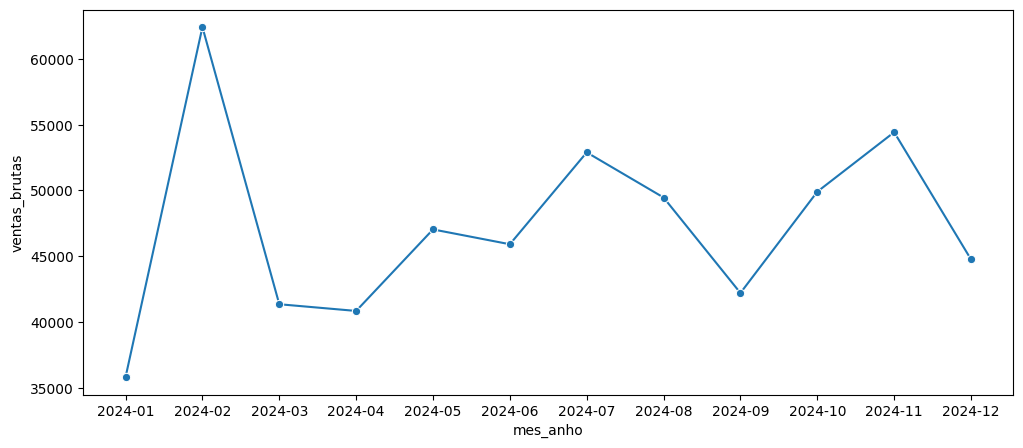

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que precio y cantidad sean numéricos
df_ventas['precio'] = pd.to_numeric(df_ventas['precio'], errors='coerce')
df_ventas['cantidad'] = pd.to_numeric(df_ventas['cantidad'], errors='coerce')

# 2. Crear ventas_brutas
df_ventas['ventas_brutas'] = df_ventas['precio'] * df_ventas['cantidad']

# 3. Convertir fecha_venta a datetime
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], format='%Y-%m-%d')

# 4. Crear columna mes/año
df_ventas['mes_anho'] = df_ventas['fecha_venta'].dt.to_period('M')

# 5. Agrupar ventas por mes
ventas_por_mes = df_ventas.groupby('mes_anho')['ventas_brutas'].sum().reset_index()

# 6. Convertir mes_anho a string para graficar
ventas_por_mes['mes_anho'] = ventas_por_mes['mes_anho'].astype(str)

# 7. Graficar
plt.figure(figsize=(12,5))
sns.lineplot(data=ventas_por_mes, x='mes_anho', y='ventas_brutas', marker='o')



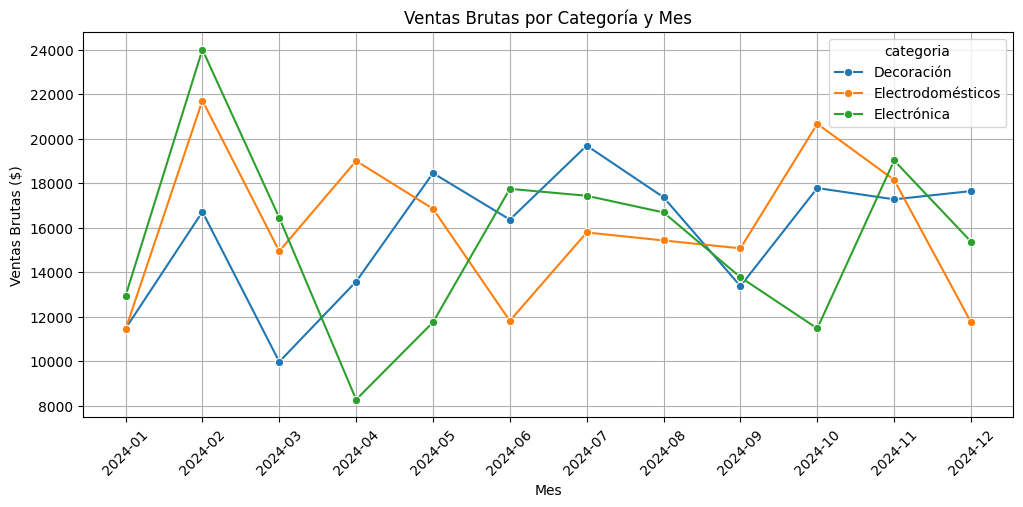

In [26]:
ventas_categoria_mes = df_ventas.groupby(['mes_anho','categoria'])['ventas_brutas'].sum().reset_index()
ventas_categoria_mes['mes_anho'] = ventas_categoria_mes['mes_anho'].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=ventas_categoria_mes, x='mes_anho', y='ventas_brutas', hue='categoria', marker='o')
plt.title('Ventas Brutas por Categoría y Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas Brutas ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


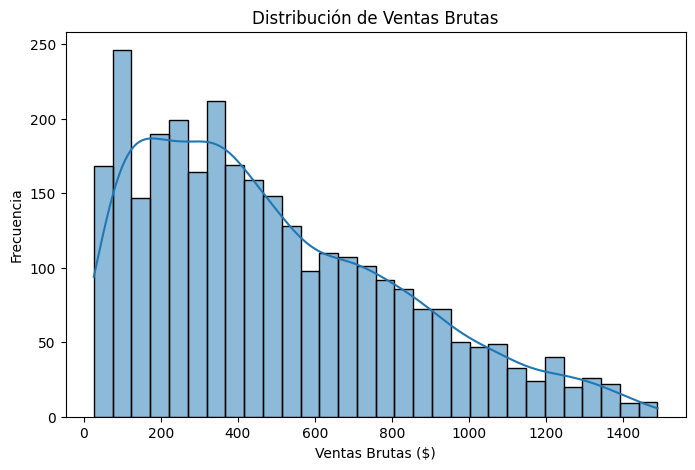

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df_ventas['ventas_brutas'], bins=30, kde=True)
plt.title('Distribución de Ventas Brutas')
plt.xlabel('Ventas Brutas ($)')
plt.ylabel('Frecuencia')
plt.show()



--- 3. Correlación entre variables numéricas ---

Matriz de Correlación:
                 precio  cantidad  ventas_brutas
precio         1.000000 -0.002388       0.558846
cantidad      -0.002388  1.000000       0.773009
ventas_brutas  0.558846  0.773009       1.000000


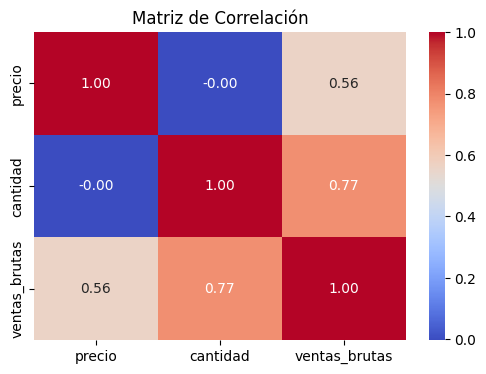


📌 Interpretación:
- Correlación entre precio y cantidad: -0.00
- Correlación entre precio y ventas_brutas: 0.56
- Correlación entre cantidad y precio: -0.00
- Correlación entre cantidad y ventas_brutas: 0.77
- Correlación entre ventas_brutas y precio: 0.56
- Correlación entre ventas_brutas y cantidad: 0.77


In [54]:
# --- 3. Correlación: Matriz de Correlación ---
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 3. Correlación entre variables numéricas ---")

# Seleccionamos columnas numéricas clave
columnas_num = ['precio', 'cantidad', 'ventas_brutas']

# Calcular correlaciones
correlaciones = df_ventas[columnas_num].corr()

# Mostrar la matriz de correlación en consola
print("\nMatriz de Correlación:")
print(correlaciones)

# Graficar la matriz de correlación
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# Interpretación breve
print("\n📌 Interpretación:")
for col in columnas_num:
    for col2 in columnas_num:
        if col != col2:
            print(f"- Correlación entre {col} y {col2}: {correlaciones.loc[col, col2]:.2f}")



================= RESUMEN FINAL DEL ANÁLISIS =================

📌 1. Estadística Descriptiva de Ventas
            precio     cantidad  ventas_brutas
count  2998.000000  2998.000000    2998.000000
mean     75.291318     6.502668     489.357412
std      28.736008     3.455107     334.281817
min      26.000000     1.000000      26.300000
25%      50.030000     3.000000     220.920000
50%      75.205000     7.000000     418.065000
75%     100.067500     9.000000     709.920000
max     124.970000    12.000000    1488.120000


📌 2. Resumen de Ventas por Categoría
           Categoría Ingresos Totales
1  Electrodomésticos      $505,299.63
2        Electrónica      $482,577.80
0         Decoración      $479,216.09


📌 3. Ventas de Alto Rendimiento (Ventas Brutas > Mediana)
  fecha_venta           producto          categoria  precio  cantidad  \
1  2024-02-01    Lámpara de mesa         Decoración  105.10       5.0   
3  2024-02-01           Heladera  Electrodomésticos  114.35       8.0   
4  

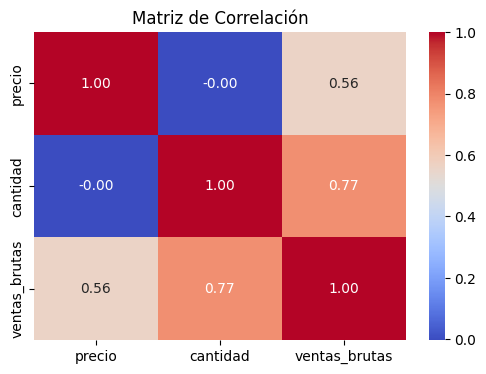


📌 Interpretación de Correlaciones:
- Correlación entre precio y cantidad: -0.00
- Correlación entre precio y ventas_brutas: 0.56
- Correlación entre cantidad y precio: -0.00
- Correlación entre cantidad y ventas_brutas: 0.77
- Correlación entre ventas_brutas y precio: 0.56
- Correlación entre ventas_brutas y cantidad: 0.77

================= FIN DEL RESUMEN =================



In [56]:
# --- 4. Consolidación de Datos: Resumen Final ---

print("\n================= RESUMEN FINAL DEL ANÁLISIS =================\n")

# 1️⃣ Estadística Descriptiva
print("📌 1. Estadística Descriptiva de Ventas")
estadisticas_ventas = df_ventas[['precio', 'cantidad', 'ventas_brutas']].describe()
print(estadisticas_ventas)
print("\n")

# 2️⃣ Resumen de Ventas por Categoría
print("📌 2. Resumen de Ventas por Categoría")
resumen_categorias = df_ventas.groupby('categoria')['ventas_brutas'].sum().reset_index()
resumen_categorias.columns = ['Categoría', 'Ingresos Totales']
resumen_categorias = resumen_categorias.sort_values(by='Ingresos Totales', ascending=False)
resumen_categorias['Ingresos Totales'] = resumen_categorias['Ingresos Totales'].map('${:,.2f}'.format)
print(resumen_categorias)
print("\n")

# 3️⃣ Tabla de Ventas de Alto Rendimiento
print("📌 3. Ventas de Alto Rendimiento (Ventas Brutas > Mediana)")
umbral_alto_rendimiento = df_ventas['ventas_brutas'].median()
df_alto_rendimiento = df_ventas[df_ventas['ventas_brutas'] > umbral_alto_rendimiento]
columnas_finales = ['fecha_venta', 'producto', 'categoria', 'precio', 'cantidad', 'ventas_brutas']
df_alto_rendimiento = df_alto_rendimiento[columnas_finales]
print(df_alto_rendimiento.head())
print(f"\nTotal de transacciones de alto rendimiento: {df_alto_rendimiento.shape[0]} / {df_ventas.shape[0]}")
print("\n")

# 4️⃣ Matriz de Correlación
print("📌 4. Matriz de Correlación entre variables numéricas")
columnas_num = ['precio', 'cantidad', 'ventas_brutas']
correlaciones = df_ventas[columnas_num].corr()
print(correlaciones)

# Graficar matriz de correlación
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# Interpretación breve
print("\n📌 Interpretación de Correlaciones:")
for col in columnas_num:
    for col2 in columnas_num:
        if col != col2:
            print(f"- Correlación entre {col} y {col2}: {correlaciones.loc[col, col2]:.2f}")

print("\n================= FIN DEL RESUMEN =================\n")


/tmp/ipython-input-1957731374.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


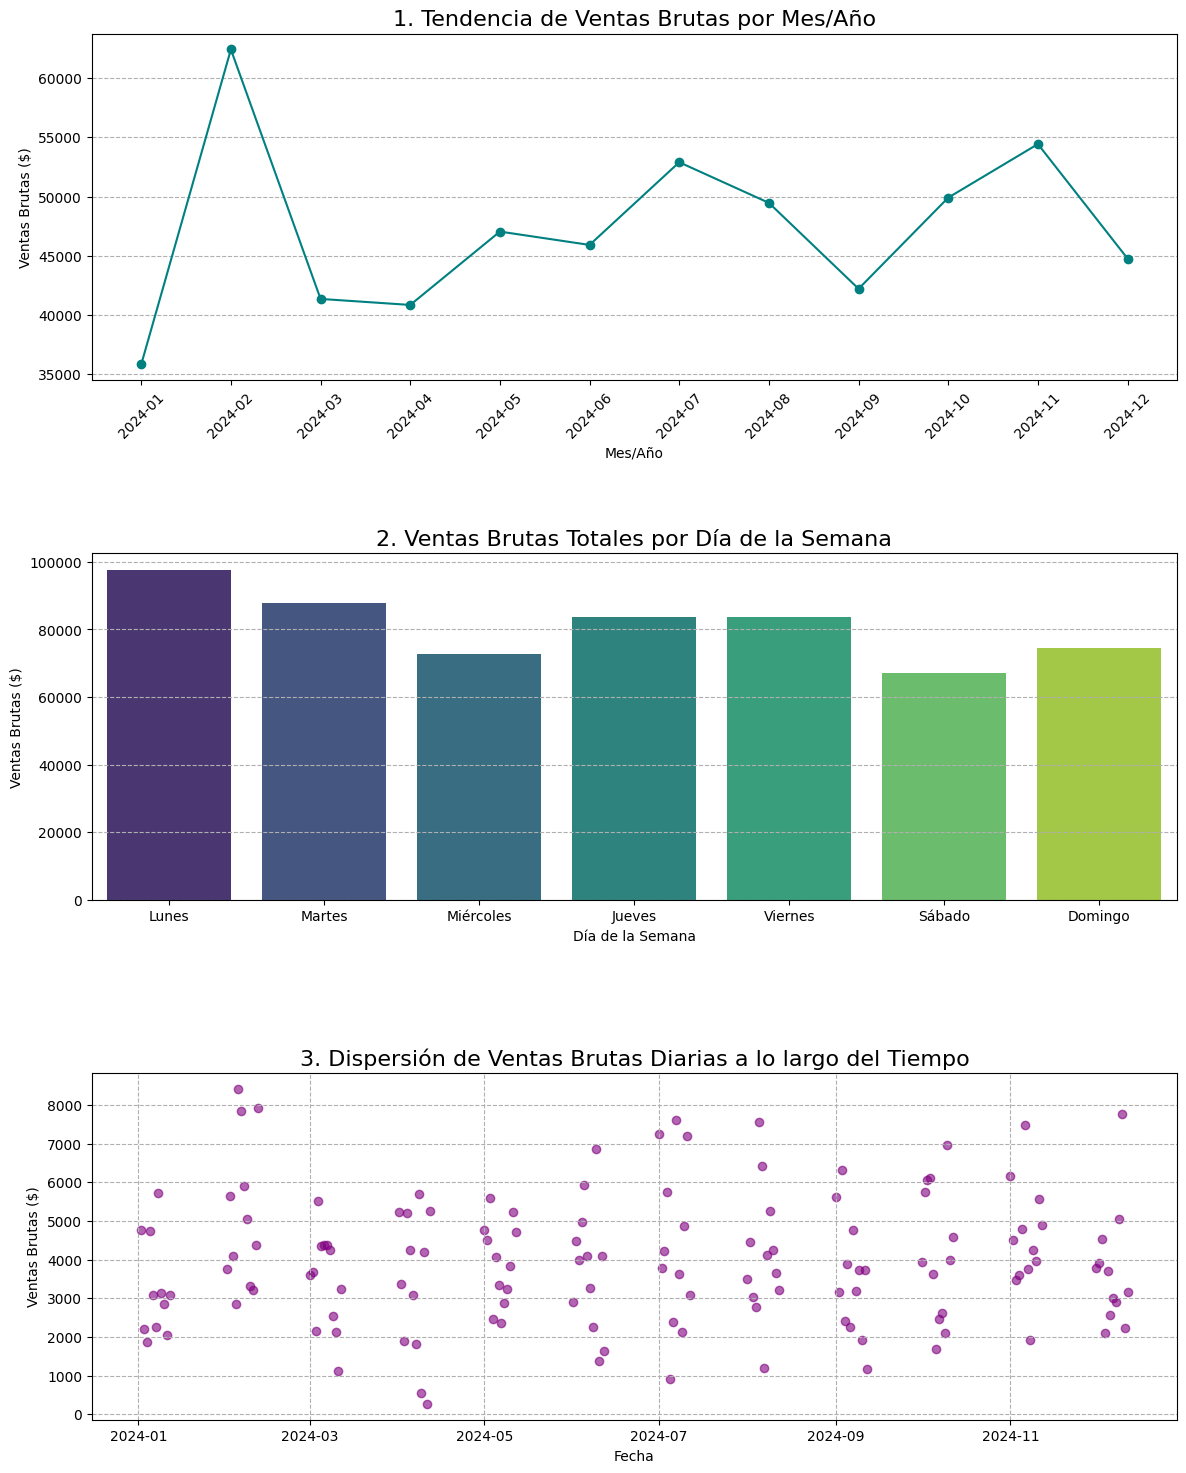

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparación de Datos (Re-asegurar columnas para los gráficos) ---
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], errors='coerce')
df_ventas['mes_anho'] = df_ventas['fecha_venta'].dt.to_period('M')
df_ventas['dia_semana'] = df_ventas['fecha_venta'].dt.dayofweek # 0=Lunes, 6=Domingo

# Agregaciones necesarias para los gráficos:
ventas_por_mes = df_ventas.groupby('mes_anho')['ventas_brutas'].sum().reset_index()
ventas_por_dia_semana = df_ventas.groupby('dia_semana')['ventas_brutas'].sum().reset_index()
ventas_diarias = df_ventas.groupby(df_ventas['fecha_venta'].dt.date)['ventas_brutas'].sum().reset_index()
ventas_diarias['fecha_venta'] = pd.to_datetime(ventas_diarias['fecha_venta'])

# Mapear nombres de días para el gráfico de barras
nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# SOLUCIÓN: Forzar la columna 'dia_semana' a tipo entero (int)
ventas_por_dia_semana['dia_semana'] = ventas_por_dia_semana['dia_semana'].astype(int)
ventas_por_dia_semana['Dia_Nombre'] = ventas_por_dia_semana['dia_semana'].map(lambda x: nombres_dias[x])

# --- 2. Creación de Subgráficos (Dashboard) ---
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18))
plt.subplots_adjust(hspace=0.5)

# Gráfico 1: LÍNEAS (Tendencia Mensual)
axes[0].plot(ventas_por_mes['mes_anho'].astype(str), ventas_por_mes['ventas_brutas'], marker='o', color='teal')
axes[0].set_title('1. Tendencia de Ventas Brutas por Mes/Año', fontsize=16)
axes[0].set_xlabel('Mes/Año')
axes[0].set_ylabel('Ventas Brutas ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, axis='y', linestyle='--')

# Gráfico 2: BARRAS (Patrón Semanal)
sns.barplot(
    ax=axes[1],
    x='Dia_Nombre',
    y='ventas_brutas',
    data=ventas_por_dia_semana,
    order=nombres_dias,
    palette='viridis'
)
axes[1].set_title('2. Ventas Brutas Totales por Día de la Semana', fontsize=16)
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Ventas Brutas ($)')
axes[1].grid(True, axis='y', linestyle='--')

# Gráfico 3: DISPERSIÓN (Ventas Diarias vs. Tiempo)
axes[2].scatter(
    ventas_diarias['fecha_venta'],
    ventas_diarias['ventas_brutas'],
    alpha=0.6,
    color='purple'
)
axes[2].set_title('3. Dispersión de Ventas Brutas Diarias a lo largo del Tiempo', fontsize=16)
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Ventas Brutas ($)')
axes[2].grid(True, linestyle='--')

# Mostrar el conjunto de gráficos
plt.show()


--- 1. Gráfico de Caja (Box Plot): Distribución de Precio por Categoría ---


/tmp/ipython-input-3260820200.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


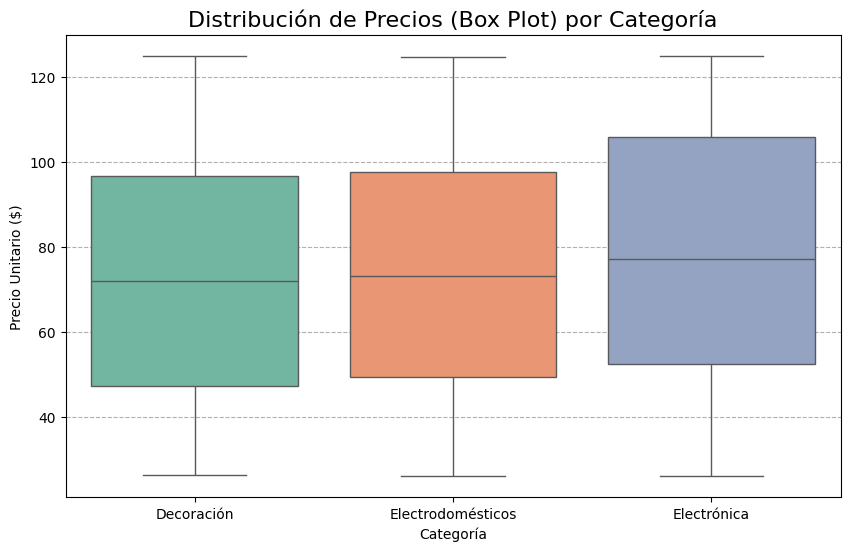


--- 2. Gráfico de Barras Agrupadas: Ventas por Categoría y Día de la Semana ---


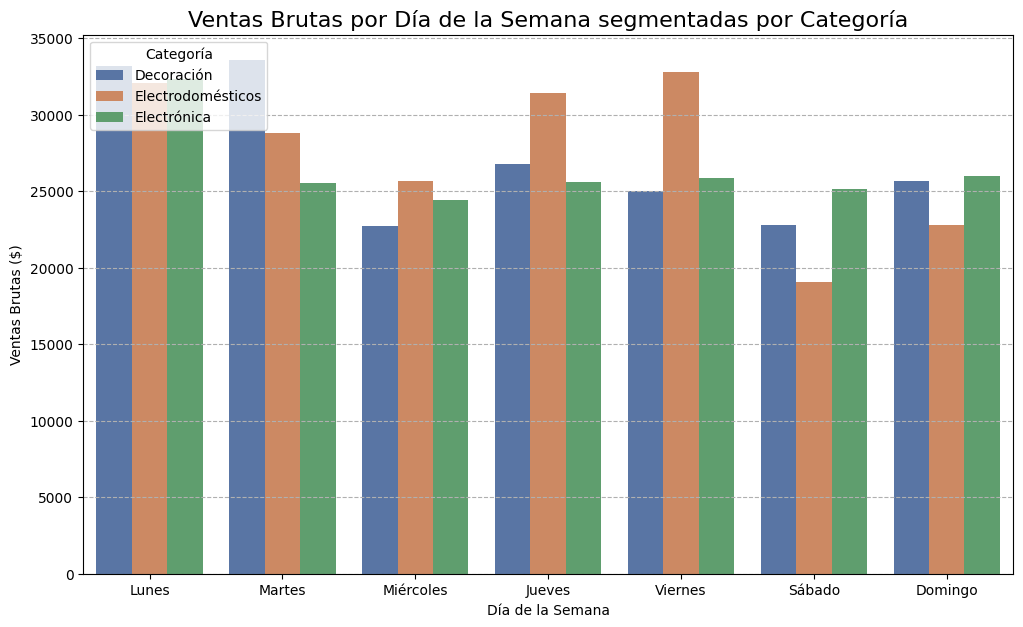

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df_ventas.dropna(subset=['fecha_venta'], inplace=True)
df_ventas['Dia_Nombre'] = df_ventas['fecha_venta'].dt.dayofweek.map(lambda x: nombres_dias[x])

print("\n--- 1. Gráfico de Caja (Box Plot): Distribución de Precio por Categoría ---")
# Se mantiene por su claridad en mostrar la mediana, cuartiles y outliers
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='categoria',
    y='precio',
    data=df_ventas,
    palette='Set2'
)
plt.title('Distribución de Precios (Box Plot) por Categoría', fontsize=16)
plt.xlabel('Categoría')
plt.ylabel('Precio Unitario ($)')
plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--')
plt.show()

print("\n--- 2. Gráfico de Barras Agrupadas: Ventas por Categoría y Día de la Semana ---")

# Agrupamos por dos variables para obtener la suma de ventas
ventas_doble_agrupacion = df_ventas.groupby(['Dia_Nombre', 'categoria'])['ventas_brutas'].sum().reset_index()

# Usamos el Gráfico de Barras Agrupadas (Clustered Bar Plot)
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Dia_Nombre', # Variable principal
    y='ventas_brutas',
    hue='categoria', # Segmentación (Agrupamiento)
    data=ventas_doble_agrupacion,
    order=nombres_dias, # Mantenemos el orden de los días
    palette='deep' # Paleta de colores avanzada
)

plt.title('Ventas Brutas por Día de la Semana segmentadas por Categoría', fontsize=16)
plt.xlabel('Día de la Semana')
plt.ylabel('Ventas Brutas ($)')
plt.xticks(rotation=0)
plt.legend(title='Categoría', loc='upper left')
plt.grid(True, axis='y', linestyle='--')
plt.show()

In [66]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# --- 1. Preparación de Datos para Plotly ---
# Aseguramos limpieza y métricas necesarias
df_ventas.dropna(subset=['fecha_venta', 'precio', 'cantidad', 'ventas_brutas', 'categoria'], inplace=True)

# 1.1 Tendencia Mensual (Línea)
ventas_por_mes = df_ventas.groupby(df_ventas['fecha_venta'].dt.to_period('M').astype(str))['ventas_brutas'].sum().reset_index()
ventas_por_mes.columns = ['Mes_Anho', 'Ventas_Brutas']

# 1.2 Ventas por Categoría (Barras)
ventas_por_categoria = df_ventas.groupby('categoria')['ventas_brutas'].sum().reset_index()

# 1.3 Scatter Plot (Usaremos una muestra si df_ventas es muy grande para mejorar la performance)
# Si tu df_ventas es > 20,000 filas, descomenta la siguiente línea:
# df_scatter = df_ventas.sample(n=1000, random_state=42)
df_scatter = df_ventas[['precio', 'cantidad', 'ventas_brutas', 'categoria']] # Usaremos el df completo

# --- 2. Creación del Dashboard con Subplots ---

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None], [{}, {}]], # 1ra fila es una sola columna, 2da son dos
    subplot_titles=("Tendencia de Ventas Brutas Mensuales",
                    "Distribución de Precio vs Cantidad (Transacciones)",
                    "Ventas Totales por Categoría"),
    vertical_spacing=0.15 # Espacio vertical entre filas
)

# GRÁFICO 1 (Fila 1, Columna 1-2): TENDENCIA MENSUAL (LÍNEA)
fig.add_trace(
    go.Scatter(
        x=ventas_por_mes['Mes_Anho'],
        y=ventas_por_mes['Ventas_Brutas'],
        mode='lines+markers',
        name='Ventas Mensuales',
        hovertemplate="Mes: %{x}<br>Ventas: $%{y:,.2f}<extra></extra>" # Formato interactivo
    ),
    row=1, col=1
)

# GRÁFICO 2 (Fila 2, Columna 1): DISPERSIÓN INTERACTIVA (SCATTER)
fig.add_trace(
    go.Scatter(
        x=df_scatter['cantidad'],
        y=df_scatter['precio'],
        mode='markers',
        marker=dict(size=8, opacity=0.6, color=df_scatter['ventas_brutas'], colorscale='Plasma', colorbar=dict(title='Ventas Brutas')),
        name='Transacciones',
        hovertemplate="Cantidad: %{x}<br>Precio Unitario: $%{y:,.2f}<br>Venta Bruta: $%{marker.color:,.2f}<extra></extra>"
    ),
    row=2, col=1
)

# GRÁFICO 3 (Fila 2, Columna 2): VENTAS POR CATEGORÍA (BARRAS)
fig.add_trace(
    go.Bar(
        x=ventas_por_categoria['categoria'],
        y=ventas_por_categoria['ventas_brutas'],
        name='Ventas',
        marker_color=['#005A9C', '#FFCC00', '#C40000'], # Colores personalizados
        hovertemplate="Categoría: %{x}<br>Total Vendido: $%{y:,.2f}<extra></extra>"
    ),
    row=2, col=2
)

# --- 3. Personalización del Dashboard ---

fig.update_layout(
    title_text="<b>Dashboard Interactivo de Análisis de Ventas</b>",
    height=900,
    showlegend=False,
    template="plotly_white" # Estilo limpio y profesional
)

# Ejes para Gráfico 1
fig.update_xaxes(title_text="Mes/Año", row=1, col=1)
fig.update_yaxes(title_text="Ventas Brutas ($)", row=1, col=1)

# Ejes para Gráfico 2 (Scatter)
fig.update_xaxes(title_text="Cantidad Vendida", row=2, col=1)
fig.update_yaxes(title_text="Precio Unitario ($)", row=2, col=1)

# Ejes para Gráfico 3 (Barras)
fig.update_xaxes(title_text="Categoría", row=2, col=2)
fig.update_yaxes(title_text="Ventas Brutas Totales ($)", row=2, col=2)

fig.show()

In [72]:
# Clonamos el repositorio
!git clone https://github.com/Josev21/TPI-Data-Analytics.git

%cd TPI-Data-Analytics

Cloning into 'TPI-Data-Analytics'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 33.82 KiB | 577.00 KiB/s, done.
/content/TPI-Data-Analytics


In [74]:
# Aseguramos que estamos en la carpeta del repositorio
%cd /content/TPI-Data-Analytics

# 1. Mover el Notebook actualizado desde tu Drive a la carpeta clonada
!cp "/content/drive/MyDrive/Colab Notebooks/data analytcs.ipynb" .

# 2. Revisar el estado para confirmar que el archivo está modificado/nuevo
!git status

/content/TPI-Data-Analytics
cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/data analytcs.ipynb': No such file or directory
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
